In [ ]:
import pandas as pd
raw=pd.read_csv('../1.ML/app/test_dataset.csv') 
raw['target']=raw['target'].str.replace("'", '"', regex=False).str.replace(" ", ",", regex=False)

In [2]:
import pandas as pd

model_names = {
    "Qwen2.5-3B-Instruct": "Qwen/Qwen2.5-3B-Instruct",
    "meta-llama/Llama-3.2-3B-Instruct": "meta-llama/Llama-3.2-3B-Instruct",
    "Phi-4-mini-instruct": "microsoft/Phi-4-mini-instruct",
}

model_names=model_names.keys()
models = [m for m in model_names]

OpensourceModel = pd.read_csv("../2.LM/OpensourceModel.csv")
ag_OpensourceModel = pd.read_csv("../3.Agent_Combine_ML/ag_OpensourceModel.csv")

for model in models:

    raw[model] = OpensourceModel[model]
    raw[f"{model}_description"] = OpensourceModel[f"{model}_description"]
    
    raw[f"ag_{model}"] = ag_OpensourceModel[f"ag_{model}"]
    raw[f"ag_{model}_description"] = ag_OpensourceModel[f"ag_{model}_description"]

LM_Claude = pd.read_csv("../2.LM/claude/Claude.csv")
Agentic_Claude = pd.read_csv("../3.Agent_Combine_ML/claude/Claude.csv")
raw[f"Claude"] = LM_Claude["Claude"]
raw[f"Claude_description"] = LM_Claude["Claude_description"]
raw[f"ag_Claude"] = Agentic_Claude["ag_Claude"]
raw[f"ag_Claude_description"] = Agentic_Claude["ag_Claude_description"]

In [3]:
df = pd.read_csv(f"../1.ML/app/ml.csv")
raw["ml"] = df["ml"]
raw[f"ml_description"] = df[f"ml_description"]

In [4]:
import ast

columns_to_eval = (
    ['ml']
    + [model for model in model_names]
    + ['Claude']
    + ['ag_' + model for model in model_names]
    + ['ag_Claude']
)
for col in columns_to_eval:
    raw[col] = raw[col].apply(ast.literal_eval)

In [5]:
# Compute ratio and length
for col in columns_to_eval:
    print(col)
    raw[f"{col}_ratio"] = raw.apply(lambda row: sum(1 for code in row[col] if code in row['target']), axis=1) / raw[col].apply(len)
    raw[f'{col}_len'] = raw[col].apply(len)

ml
Qwen2.5-3B-Instruct
meta-llama/Llama-3.2-3B-Instruct
Phi-4-mini-instruct
Claude
ag_Qwen2.5-3B-Instruct
ag_meta-llama/Llama-3.2-3B-Instruct
ag_Phi-4-mini-instruct
ag_Claude


In [6]:
raw.fillna(0, inplace=True)

In [7]:
cols = [
 'ml_ratio','ml_len',
 'Qwen2.5-3B-Instruct_ratio','Qwen2.5-3B-Instruct_len',
 'meta-llama/Llama-3.2-3B-Instruct_ratio','meta-llama/Llama-3.2-3B-Instruct_len',
 'Phi-4-mini-instruct_ratio','Phi-4-mini-instruct_len',
 'Claude_ratio','Claude_len',
 'ag_Qwen2.5-3B-Instruct_ratio','ag_Qwen2.5-3B-Instruct_len',
 'ag_meta-llama/Llama-3.2-3B-Instruct_ratio','ag_meta-llama/Llama-3.2-3B-Instruct_len',
 'ag_Phi-4-mini-instruct_ratio','ag_Phi-4-mini-instruct_len',
 'ag_Claude_ratio','ag_Claude_len'
]
use_cols = [c for c in cols if c in raw.columns]
means = raw[use_cols].mean(numeric_only=True)
for c, v in means.items():
    print(f"{c}: {v:.4f}")

ml_ratio: 0.5589
ml_len: 15.0000
Qwen2.5-3B-Instruct_ratio: 0.0492
Qwen2.5-3B-Instruct_len: 4.8664
meta-llama/Llama-3.2-3B-Instruct_ratio: 0.0158
meta-llama/Llama-3.2-3B-Instruct_len: 5.8719
Phi-4-mini-instruct_ratio: 0.1246
Phi-4-mini-instruct_len: 6.9820
Claude_ratio: 0.3464
Claude_len: 9.8084
ag_Qwen2.5-3B-Instruct_ratio: 0.3702
ag_Qwen2.5-3B-Instruct_len: 1.9730
ag_meta-llama/Llama-3.2-3B-Instruct_ratio: 0.5515
ag_meta-llama/Llama-3.2-3B-Instruct_len: 3.9847
ag_Phi-4-mini-instruct_ratio: 0.4551
ag_Phi-4-mini-instruct_len: 6.9600
ag_Claude_ratio: 0.5266
ag_Claude_len: 7.8840


In [ ]:
raw['document_length']= raw['text'].str.len()
raw = raw.sort_values(by="document_length", ascending=True)  
# raw.to_excel("eval.csv", index=False)

In [9]:
min_val = raw['document_length'].min()
max_val = raw['document_length'].max()
print(min_val, max_val)


1093 47419


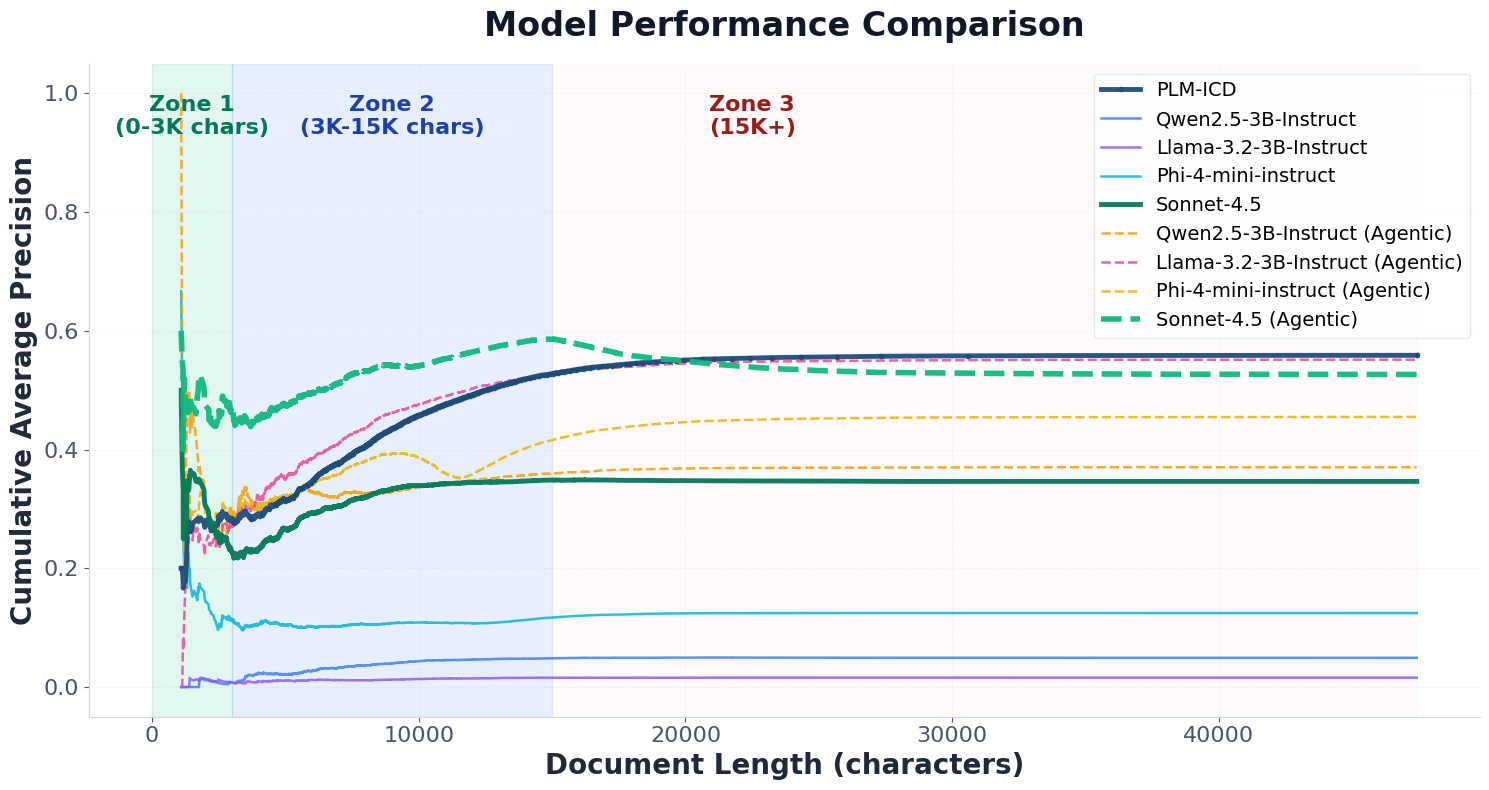

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

cols = [
    "ml_ratio",
    "Qwen2.5-3B-Instruct_ratio",
    "meta-llama/Llama-3.2-3B-Instruct_ratio",
    "Phi-4-mini-instruct_ratio",
    "Claude_ratio",
    "ag_Qwen2.5-3B-Instruct_ratio",
    "ag_meta-llama/Llama-3.2-3B-Instruct_ratio",
    "ag_Phi-4-mini-instruct_ratio",
    "ag_Claude_ratio"
]

# mapping ชื่อที่ต้องการแสดง (ให้ตรงตามภาพ)
label_map = {
    "ml_ratio": "PLM-ICD",
    "Qwen2.5-3B-Instruct_ratio": "Qwen2.5-3B-Instruct",
    "meta-llama/Llama-3.2-3B-Instruct_ratio": "Llama-3.2-3B-Instruct",
    "Phi-4-mini-instruct_ratio": "Phi-4-mini-instruct",
    "Claude_ratio": "Sonnet-4.5",
    "ag_Qwen2.5-3B-Instruct_ratio": "Qwen2.5-3B-Instruct (Agentic)",
    "ag_meta-llama/Llama-3.2-3B-Instruct_ratio": "Llama-3.2-3B-Instruct (Agentic)",
    "ag_Phi-4-mini_instruct_ratio": "Phi-4-mini-instruct (Agentic)",  # กันพิมพ์ผิดไว้ (ถ้ามี)
    "ag_Phi-4-mini-instruct_ratio": "Phi-4-mini-instruct (Agentic)",
    "ag_Claude_ratio": "Sonnet-4.5 (Agentic)"
}

# สี palette
colors = {
    'ml': '#1E4D7B',
    'qwen': '#3B82F6',
    'llama': '#8B5CF6',
    'phi': '#06B6D4',
    'claude': '#047857',
    'ag_qwen': '#F59E0B',
    'ag_llama': '#EC4899',
    'ag_phi': '#EAB308',
    'ag_claude': '#10B981'
}

linewidths = {
    'ml': 3.5,
    'claude': 3.5,
    'ag_claude': 4,
    'default': 1.8
}

def style_key(col: str) -> str:
    """Map column name -> style key in colors/linewidths."""
    if col == "ml_ratio":
        return "ml"
    if col.startswith("ag_"):
        if "Qwen2.5-3B-Instruct" in col:
            return "ag_qwen"
        if "meta-llama/Llama-3.2-3B-Instruct" in col:
            return "ag_llama"
        if "Phi-4-mini-instruct" in col or "Phi-4-mini_instruct" in col:
            return "ag_phi"
        if "Claude" in col:
            return "ag_claude"
        return "ag_"
    else:
        if col.startswith("Qwen2.5-3B-Instruct"):
            return "qwen"
        if col.startswith("meta-llama/Llama-3.2-3B-Instruct"):
            return "llama"
        if col.startswith("Phi-4-mini-instruct"):
            return "phi"
        if col.startswith("Claude"):
            return "claude"
    return "default"

fig, ax = plt.subplots(figsize=(15, 8))

for col in cols:
    if col in raw.columns:
        cum_mean = raw[col].expanding().mean()
        label = label_map.get(col, col)

        key = style_key(col)
        color = colors.get(key, '#D1D5DB')
        lw = linewidths.get(key, linewidths['default'])

        if col == "ml_ratio":
            ax.plot(raw["document_length"], cum_mean, label=label, color=color,
                    linewidth=lw, alpha=0.95, zorder=4, marker='o', markersize=3, markevery=100)
        elif col.startswith("ag_"):
            ls = '--'
            z = 5 if key == 'ag_claude' else 2
            a = 0.95 if key == 'ag_claude' else 0.85
            ax.plot(raw["document_length"], cum_mean, label=label, color=color,
                    linewidth=lw, linestyle=ls, alpha=a, zorder=z)
        else:
            z = 4 if key == 'claude' else 1
            a = 0.95 if key == 'claude' else 0.85
            ax.plot(raw["document_length"], cum_mean, label=label, color=color,
                    linewidth=lw, alpha=a, zorder=z)

# y limits
y_min, y_max = ax.get_ylim()

# Shaded zones
ax.axvspan(0, 3000, alpha=0.12, color='#10B981', zorder=0)
ax.axvspan(3000, 15000, alpha=0.12, color='#3B82F6', zorder=0)
ax.axvspan(15000, raw["document_length"].max(), alpha=0.12, color='#FED7D7', zorder=0)

# Zone labels
ax.text(1500, y_max * 0.95, 'Zone 1\n(0-3K chars)',
        ha='center', va='top', fontsize=16, fontweight='600', color='#047857')
ax.text(9000, y_max * 0.95, 'Zone 2\n(3K-15K chars)',
        ha='center', va='top', fontsize=16, fontweight='600', color='#1E40AF')
ax.text(22500, y_max * 0.95, 'Zone 3\n(15K+)',
        ha='center', va='top', fontsize=16, fontweight='600', color='#991B1B')

# Styling
ax.set_xlabel("Document Length (characters)", fontsize=20, fontweight='600', color='#1F2937')
ax.set_ylabel("Cumulative Average Precision", fontsize=20, fontweight='600', color='#1F2937')
ax.set_title("Model Performance Comparison", fontsize=24, fontweight='bold', pad=20, color='#111827')

ax.legend(loc='upper right',
          fontsize=14, frameon=True, framealpha=0.95,
          edgecolor='#E5E7EB', fancybox=True, shadow=False)

ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.5, color='#9CA3AF')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#D1D5DB')
ax.spines['bottom'].set_color('#D1D5DB')
ax.tick_params(colors='#4B5563', labelsize=16)

ax.set_facecolor('#FFFFFF')
fig.patch.set_facecolor('#FFFFFF')

plt.tight_layout()
plt.show()

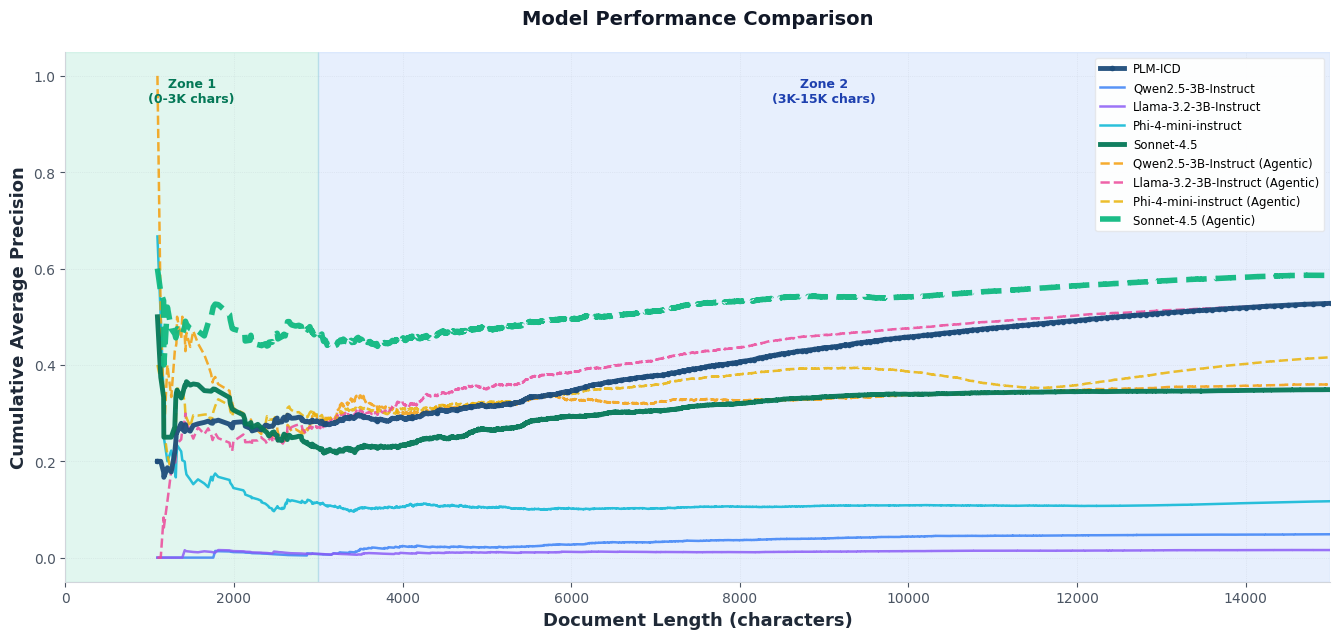

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

cols = [
    "ml_ratio",
    "Qwen2.5-3B-Instruct_ratio",
    "meta-llama/Llama-3.2-3B-Instruct_ratio",
    "Phi-4-mini-instruct_ratio",
    "Claude_ratio",
    "ag_Qwen2.5-3B-Instruct_ratio",
    "ag_meta-llama/Llama-3.2-3B-Instruct_ratio",
    "ag_Phi-4-mini-instruct_ratio",
    "ag_Claude_ratio"
]

# mapping ชื่อที่ต้องการแสดง (ให้ตรงตามภาพ)
label_map = {
    "ml_ratio": "PLM-ICD",
    "Qwen2.5-3B-Instruct_ratio": "Qwen2.5-3B-Instruct",
    "meta-llama/Llama-3.2-3B-Instruct_ratio": "Llama-3.2-3B-Instruct",
    "Phi-4-mini-instruct_ratio": "Phi-4-mini-instruct",
    "Claude_ratio": "Sonnet-4.5",
    "ag_Qwen2.5-3B-Instruct_ratio": "Qwen2.5-3B-Instruct (Agentic)",
    "ag_meta-llama/Llama-3.2-3B-Instruct_ratio": "Llama-3.2-3B-Instruct (Agentic)",
    "ag_Phi-4-mini-instruct_ratio": "Phi-4-mini-instruct (Agentic)",
    "ag_Claude_ratio": "Sonnet-4.5 (Agentic)"
}

# สี palette ที่สดใสและมองเห็นได้ชัดเจน
colors = {
    'ml': '#1E4D7B',      # น้ำเงินเข้ม - ML
    'qwen': '#3B82F6',    # น้ำเงินสด
    'llama': '#8B5CF6',   # ม่วงสด
    'phi': '#06B6D4',     # ฟ้าสด (cyan)
    'claude': '#047857',  # เขียวเข้ม
    'ag_qwen': '#F59E0B',     # ส้มสด
    'ag_llama': '#EC4899',    # ชมพูสด
    'ag_phi': '#EAB308',      # เหลืองสด
    'ag_claude': '#10B981'    # เขียวสด
}

linewidths = {
    'ml': 3.5,
    'claude': 3.5,
    'ag_claude': 4,
    'default': 1.8
}

fig, ax = plt.subplots(figsize=(13.5, 6.5))

# วาดกราฟเส้น
for col in cols:
    if col in raw.columns:
        cum_mean = raw[col].expanding().mean()
        label = label_map.get(col, col)

        # กำหนดสีและความหนา (เดิม)
        color = colors.get(
            col.replace('_ratio', '')
               .replace('Qwen2.5-3B-Instruct', 'qwen')
               .replace('meta-llama/Llama-3.2-3B-Instruct', 'llama')
               .replace('Phi-4-mini-instruct', 'phi')
               .replace('Claude', 'claude')
               .replace('ag_', 'ag_'),
            '#D1D5DB'
        )
        lw = linewidths.get(
            col.replace('_ratio', '')
               .replace('Qwen2.5-3B-Instruct', 'qwen')
               .replace('meta-llama/Llama-3.2-3B-Instruct', 'llama')
               .replace('Phi-4-mini-instruct', 'phi')
               .replace('Claude', 'claude')
               .replace('ag_', 'ag_'),
            linewidths['default']
        )

        # วาดเส้น
        if 'ml_ratio' in col:
            ax.plot(raw["document_length"], cum_mean, label=label, color=color,
                    linewidth=lw, alpha=0.95, zorder=4, marker='o', markersize=3, markevery=100)
        elif 'ag_' in col.lower():
            if 'claude' in col.lower():
                ax.plot(raw["document_length"], cum_mean, label=label, color=color,
                        linewidth=lw, linestyle='--', alpha=0.95, zorder=5)
            else:
                ax.plot(raw["document_length"], cum_mean, label=label, color=color,
                        linewidth=lw, linestyle='--', alpha=0.85, zorder=2)
        else:
            if 'claude' in col.lower():
                ax.plot(raw["document_length"], cum_mean, label=label, color=color,
                        linewidth=lw, alpha=0.95, zorder=4)
            else:
                ax.plot(raw["document_length"], cum_mean, label=label, color=color,
                        linewidth=lw, alpha=0.85, zorder=1)

# หาค่า y limits
y_min, y_max = ax.get_ylim()

# จำกัดแกน x ให้แสดงเฉพาะ Zone 1 และ Zone 2
ax.set_xlim(0, 15000)

# Shaded zones - 0-3000, 3000-15000
ax.axvspan(0, 3000, alpha=0.12, color='#10B981', zorder=0)
ax.axvspan(3000, 15000, alpha=0.12, color='#3B82F6', zorder=0)

# เพิ่ม text annotations สำหรับ zones
ax.text(1500, y_max * 0.95, 'Zone 1\n(0-3K chars)',
        ha='center', va='top', fontsize=9, fontweight='600', color='#047857')
ax.text(9000, y_max * 0.95, 'Zone 2\n(3K-15K chars)',
        ha='center', va='top', fontsize=9, fontweight='600', color='#1E40AF')

# Styling
ax.set_xlabel("Document Length (characters)", fontsize=13, fontweight='600', color='#1F2937')
ax.set_ylabel("Cumulative Average Precision", fontsize=13, fontweight='600', color='#1F2937')
ax.set_title("Model Performance Comparison",
             fontsize=14, fontweight='bold', pad=20, color='#111827')

ax.legend(loc='upper right',
          fontsize=8.5,
          frameon=True,
          framealpha=0.95,
          edgecolor='#E5E7EB',
          fancybox=True,
          shadow=False)

ax.grid(True, alpha=0.25, linestyle=':', linewidth=0.5, color='#9CA3AF')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#D1D5DB')
ax.spines['bottom'].set_color('#D1D5DB')
ax.tick_params(colors='#4B5563', labelsize=10)

ax.set_facecolor('#FFFFFF')
fig.patch.set_facecolor('#FFFFFF')

plt.tight_layout()
plt.show()

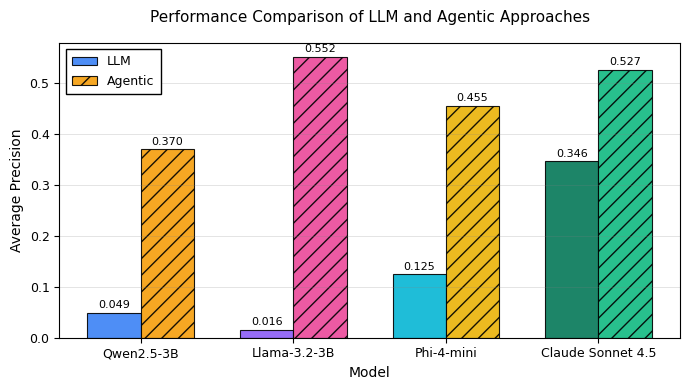

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Define models and calculate average scores
models = ['Qwen2.5-3B', 'Llama-3.2-3B', 'Phi-4-mini', 'Claude Sonnet 4.5']

# Calculate mean scores for each model
non_agentic_scores = [
    raw["Qwen2.5-3B-Instruct_ratio"].mean(),
    raw["meta-llama/Llama-3.2-3B-Instruct_ratio"].mean(),
    raw["Phi-4-mini-instruct_ratio"].mean(),
    raw["Claude_ratio"].mean()
]

agentic_scores = [
    raw["ag_Qwen2.5-3B-Instruct_ratio"].mean(),
    raw["ag_meta-llama/Llama-3.2-3B-Instruct_ratio"].mean(),
    raw["ag_Phi-4-mini-instruct_ratio"].mean(),
    raw["ag_Claude_ratio"].mean()
]

# Set up the figure with IEEE LLM size (column width or double column)
fig, ax = plt.subplots(figsize=(7, 4))  # IEEE column width

x = np.arange(len(models))
width = 0.35

# Color scheme (keeping your preferred colors)
colors_non_agentic = ['#3B82F6', '#8B5CF6', '#06B6D4', '#047857']
colors_agentic = ['#F59E0B', '#EC4899', '#EAB308', '#10B981']

# Create bars with hatching patterns for better b&w printing
bars1 = ax.bar(x - width/2, non_agentic_scores, width, 
               label='LLM', color=colors_non_agentic, 
               alpha=0.9, edgecolor='black', linewidth=0.8)

bars2 = ax.bar(x + width/2, agentic_scores, width, 
               label='Agentic', color=colors_agentic, 
               alpha=0.9, edgecolor='black', linewidth=0.8, hatch='//')

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='normal')

add_value_labels(bars1)
add_value_labels(bars2)

# IEEE-style formatting
ax.set_xlabel('Model', fontsize=10, fontweight='normal')
ax.set_ylabel('Average Precision', fontsize=10, fontweight='normal')
ax.set_title('Performance Comparison of LLM and Agentic Approaches',
             fontsize=11, fontweight='normal', pad=15)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9, rotation=0)

# Legend with IEEE style
ax.legend(fontsize=9, frameon=True, framealpha=1, 
         edgecolor='black', fancybox=False, loc='upper left',
         borderpad=0.5, handlelength=2)

# Grid and spines - IEEE prefers minimal grid
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, color='gray', axis='y')
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['top'].set_linewidth(0.8)
ax.spines['right'].set_linewidth(0.8)

ax.tick_params(colors='black', labelsize=9, width=0.8)

# Set y-axis to start from 0 for better comparison
ax.set_ylim(bottom=0)

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()

# Save as high-resolution for IEEE submission
plt.savefig('model_comparison.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight', format='png')
plt.show()

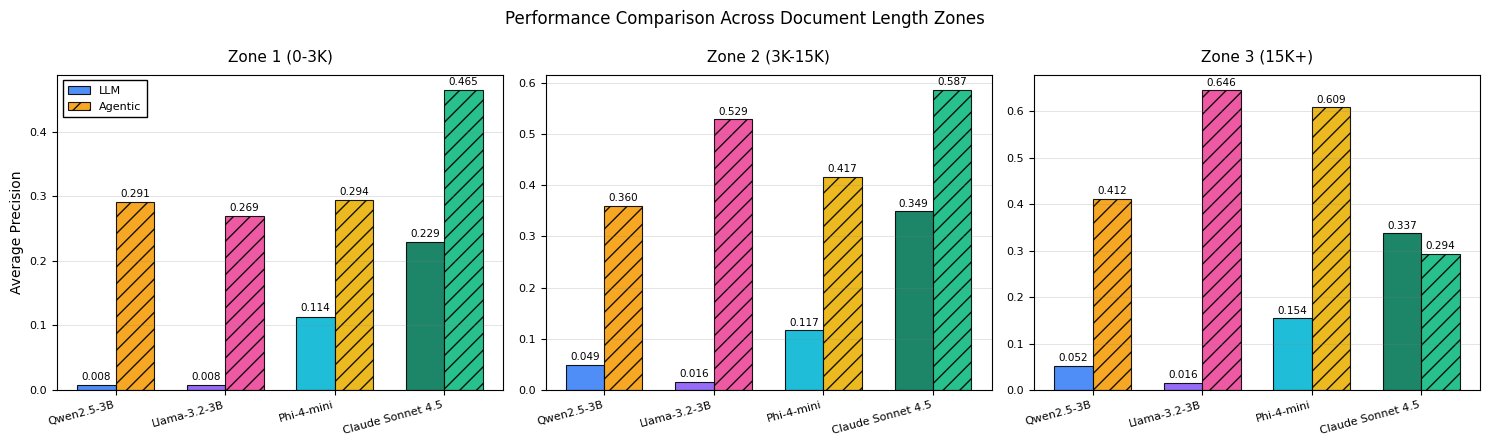

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Define zones
zones = {
    'Zone 1 (0-3K)': (0, 3000),
    'Zone 2 (3K-15K)': (3000, 15000),
    'Zone 3 (15K+)': (15000, raw["document_length"].max())
}

models = ['Qwen2.5-3B', 'Llama-3.2-3B', 'Phi-4-mini', 'Claude Sonnet 4.5']

# Column mappings
col_mapping = {
    'Qwen2.5-3B': ('Qwen2.5-3B-Instruct_ratio', 'ag_Qwen2.5-3B-Instruct_ratio'),
    'Llama-3.2-3B': ('meta-llama/Llama-3.2-3B-Instruct_ratio', 'ag_meta-llama/Llama-3.2-3B-Instruct_ratio'),
    'Phi-4-mini': ('Phi-4-mini-instruct_ratio', 'ag_Phi-4-mini-instruct_ratio'),
    'Claude Sonnet 4.5': ('Claude_ratio', 'ag_Claude_ratio')
}

# Color scheme
colors_non_agentic = ['#3B82F6', '#8B5CF6', '#06B6D4', '#047857']
colors_agentic = ['#F59E0B', '#EC4899', '#EAB308', '#10B981']

# Create subplots for 3 zones
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, (zone_name, (start, end)) in enumerate(zones.items()):
    ax = axes[idx]
    
    # Filter data for this zone
    mask = (raw["document_length"] >= start) & (raw["document_length"] <= end)
    zone_data = raw[mask]
    
    # Calculate average scores for each model in this zone
    non_agentic_scores = []
    agentic_scores = []
    
    for model in models:
        non_ag_col, ag_col = col_mapping[model]
        non_agentic_scores.append(zone_data[non_ag_col].mean())
        agentic_scores.append(zone_data[ag_col].mean())
    
    # Create bars
    x = np.arange(len(models))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, non_agentic_scores, width, 
                   label='LLM', color=colors_non_agentic, 
                   alpha=0.9, edgecolor='black', linewidth=0.8)
    
    bars2 = ax.bar(x + width/2, agentic_scores, width, 
                   label='Agentic', color=colors_agentic, 
                   alpha=0.9, edgecolor='black', linewidth=0.8, hatch='//')
    
    # Add value labels
    def add_value_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=7.5, fontweight='normal')
    
    add_value_labels(bars1)
    add_value_labels(bars2)
    
    # Styling
    ax.set_title(zone_name, fontsize=11, fontweight='normal', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=8, rotation=15, ha='right')
    
    if idx == 0:
        ax.set_ylabel('Average Precision', fontsize=10, fontweight='normal')
        ax.legend(fontsize=8, frameon=True, framealpha=1, 
                 edgecolor='black', fancybox=False, loc='upper left',
                 borderpad=0.5, handlelength=2)
    
    # Grid and spines
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, color='gray', axis='y')
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(0.8)
    
    ax.tick_params(colors='black', labelsize=8, width=0.8)
    ax.set_ylim(bottom=0)
    ax.set_facecolor('white')

fig.suptitle('Performance Comparison Across Document Length Zones', 
             fontsize=12, fontweight='normal', y=0.98)
fig.patch.set_facecolor('white')

plt.tight_layout()



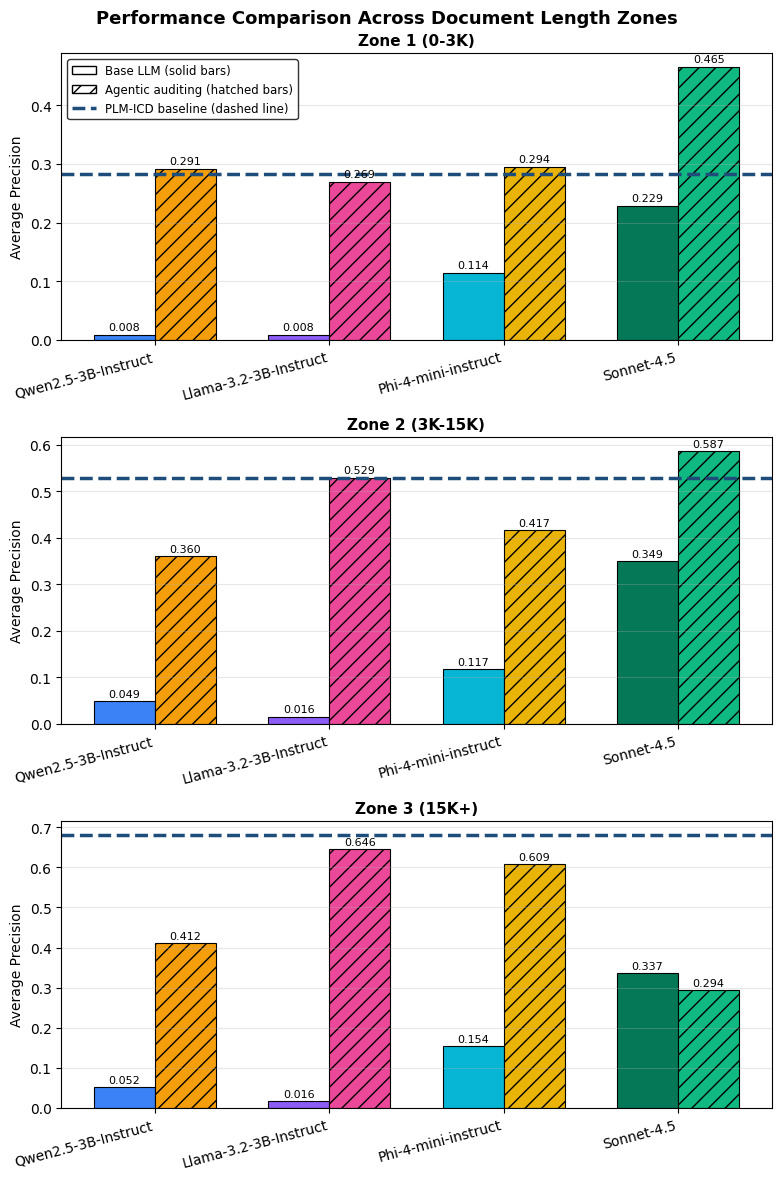

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Define zones
zones = {
    'Zone 1 (0-3K)': (0, 3000),
    'Zone 2 (3K-15K)': (3000, 15000),
    'Zone 3 (15K+)': (15000, raw["document_length"].max())
}

# Internal model keys
models = ['Qwen2.5-3B', 'Llama-3.2-3B', 'Phi-4-mini', 'Claude Sonnet 4.5']

# Display names (consistent with paper)
display_name = {
    'Qwen2.5-3B': 'Qwen2.5-3B-Instruct',
    'Llama-3.2-3B': 'Llama-3.2-3B-Instruct',
    'Phi-4-mini': 'Phi-4-mini-instruct',
    'Claude Sonnet 4.5': 'Sonnet-4.5'
}

# Column mapping
col_mapping = {
    'Qwen2.5-3B': ('Qwen2.5-3B-Instruct_ratio', 'ag_Qwen2.5-3B-Instruct_ratio'),
    'Llama-3.2-3B': ('meta-llama/Llama-3.2-3B-Instruct_ratio', 'ag_meta-llama/Llama-3.2-3B-Instruct_ratio'),
    'Phi-4-mini': ('Phi-4-mini-instruct_ratio', 'ag_Phi-4-mini-instruct_ratio'),
    'Claude Sonnet 4.5': ('Claude_ratio', 'ag_Claude_ratio')
}

# Colors
colors_non_agentic = ['#3B82F6', '#8B5CF6', '#06B6D4', '#047857']
colors_agentic = ['#F59E0B', '#EC4899', '#EAB308', '#10B981']
ml_color = '#1E4D7B'

# Create figure
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

for idx, (zone_name, (start, end)) in enumerate(zones.items()):
    ax = axes[idx]

    # Filter data
    mask = (raw["document_length"] >= start) & (raw["document_length"] <= end)
    zone_data = raw[mask]

    # ML baseline
    ml_baseline = zone_data['ml_ratio'].mean()

    non_agentic_scores = []
    agentic_scores = []

    for model in models:
        non_ag_col, ag_col = col_mapping[model]
        non_agentic_scores.append(zone_data[non_ag_col].mean())
        agentic_scores.append(zone_data[ag_col].mean())

    # Plot bars
    x = np.arange(len(models))
    width = 0.35

    bars1 = ax.bar(x - width/2, non_agentic_scores, width,
                   color=colors_non_agentic,
                   edgecolor='black', linewidth=0.8)

    bars2 = ax.bar(x + width/2, agentic_scores, width,
                   color=colors_agentic,
                   edgecolor='black', linewidth=0.8, hatch='//')

    # ML baseline line
    ax.axhline(y=ml_baseline, color=ml_color, linestyle='--',
               linewidth=2.5)

    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    # Axis styling
    ax.set_title(zone_name, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([display_name[m] for m in models], rotation=15, ha='right')
    ax.set_ylabel('Average Precision')
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_ylim(bottom=0)

    # ===== Encoding legend ONLY =====
    if idx == 0:
        method_patches = [
            Patch(facecolor='white', edgecolor='black',
                  label='Base LLM (solid bars)'),
            Patch(facecolor='white', edgecolor='black', hatch='//',
                  label='Agentic auditing (hatched bars)'),
            Line2D([0], [0], color=ml_color, linestyle='--', linewidth=2.5,
                   label='PLM-ICD baseline (dashed line)')
        ]

        ax.legend(handles=method_patches,
                  fontsize=8.5,
                  title_fontsize=9,
                  frameon=True,
                  edgecolor='black',
                  loc='upper left')

# Overall title
fig.suptitle('Performance Comparison Across Document Length Zones',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()